In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

# Set base path relative to notebook location
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_PATH = os.path.join(BASE_DIR, 'data', 'HR_Analytics.csv')
OUTPUT_PATH = os.path.join(BASE_DIR, 'outputs')

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output path:", OUTPUT_PATH)

Base dir: d:\Masters\Extra Projects\HR Analysis Dashboard\ml_model
Data path: d:\Masters\Extra Projects\HR Analysis Dashboard\ml_model\data\HR_Analytics.csv
Output path: d:\Masters\Extra Projects\HR Analysis Dashboard\ml_model\outputs


In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
print("Shape:", df.shape)
print("\nAttrition value counts:")
print(df['Attrition'].value_counts())
print("\nNull values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (1480, 38)

Attrition value counts:
Attrition
No     1242
Yes     238
Name: count, dtype: int64

Null values:
YearsWithCurrManager    57
dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   str    
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   str    
 3   Attrition                 1480 non-null   str    
 4   BusinessTravel            1480 non-null   str    
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   str    
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   str    
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   str    
 14  HourlyRate         

In [6]:
drop_cols = [
    'EmpID', 'EmployeeNumber', 'EmployeeCount', 
    'Over18', 'StandardHours',
    'AgeGroup', 'SalarySlab'  # derived columns — leakage risk
]
df.drop(columns=drop_cols, inplace=True)

In [7]:
# Fix the one null
df['YearsWithCurrManager'].fillna(df['YearsWithCurrManager'].median(), inplace=True)

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
1475    10.0
1476    11.0
1477     2.0
1478     9.0
1479     0.0
Name: YearsWithCurrManager, Length: 1480, dtype: float64

In [8]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [9]:
print("Cleaned shape:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())
print("Attrition balance:\n", df['Attrition'].value_counts())

Cleaned shape: (1480, 31)
Nulls remaining: 57
Attrition balance:
 Attrition
0    1242
1     238
Name: count, dtype: int64


In [10]:
print(df['YearsWithCurrManager'].isnull().sum())
print(df['YearsWithCurrManager'].dtype)

57
float64


In [11]:
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(df['YearsWithCurrManager'].median())

print("Nulls remaining:", df['YearsWithCurrManager'].isnull().sum())

Nulls remaining: 0


In [12]:
print("Cleaned shape:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())
print("Attrition balance:\n", df['Attrition'].value_counts())

Cleaned shape: (1480, 31)
Nulls remaining: 0
Attrition balance:
 Attrition
0    1242
1     238
Name: count, dtype: int64


In [13]:
binary_cols = ['OverTime', 'Gender']
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [14]:
# One-hot encode remaining categoricals
cat_cols = ['Department', 'JobRole', 'MaritalStatus', 'BusinessTravel', 'EducationField']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [15]:
print("Shape after encoding:", df.shape)
print("Remaining object columns:", df.select_dtypes(include='object').columns.tolist())

Shape after encoding: (1480, 46)
Remaining object columns: []


In [16]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain attrition balance:\n", y_train.value_counts())
print("\nTest attrition balance:\n", y_test.value_counts())

X_train shape: (1184, 45)
X_test shape: (296, 45)

Train attrition balance:
 Attrition
0    994
1    190
Name: count, dtype: int64

Test attrition balance:
 Attrition
0    248
1     48
Name: count, dtype: int64


In [19]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [20]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [21]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [22]:
print("Logistic Regression Results")
print("="*40)
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Left']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_lr), 3))

Logistic Regression Results
              precision    recall  f1-score   support

      Stayed       0.93      0.74      0.83       248
        Left       0.35      0.73      0.48        48

    accuracy                           0.74       296
   macro avg       0.64      0.74      0.65       296
weighted avg       0.84      0.74      0.77       296

ROC-AUC: 0.814


In [23]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [25]:
print("Random Forest Results")
print("="*40)
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

Random Forest Results
              precision    recall  f1-score   support

      Stayed       0.86      0.99      0.92       248
        Left       0.80      0.17      0.28        48

    accuracy                           0.86       296
   macro avg       0.83      0.58      0.60       296
weighted avg       0.85      0.86      0.82       296

ROC-AUC: 0.817


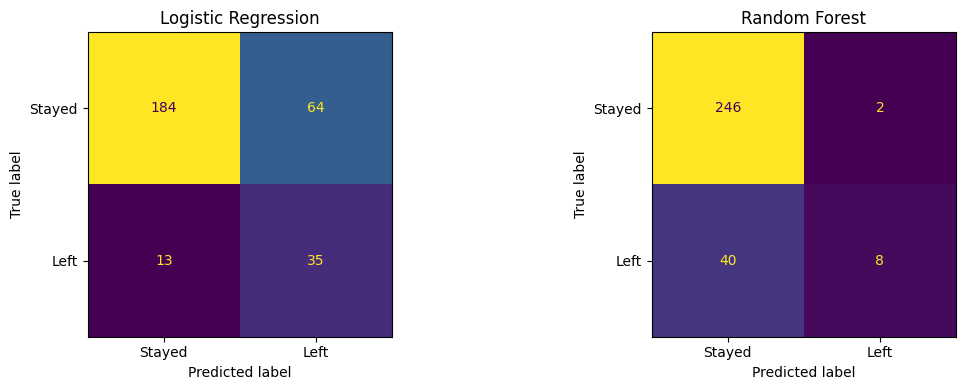

Saved to outputs/


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, 
    display_labels=['Stayed', 'Left'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, 
    display_labels=['Stayed', 'Left'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'filename.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/")

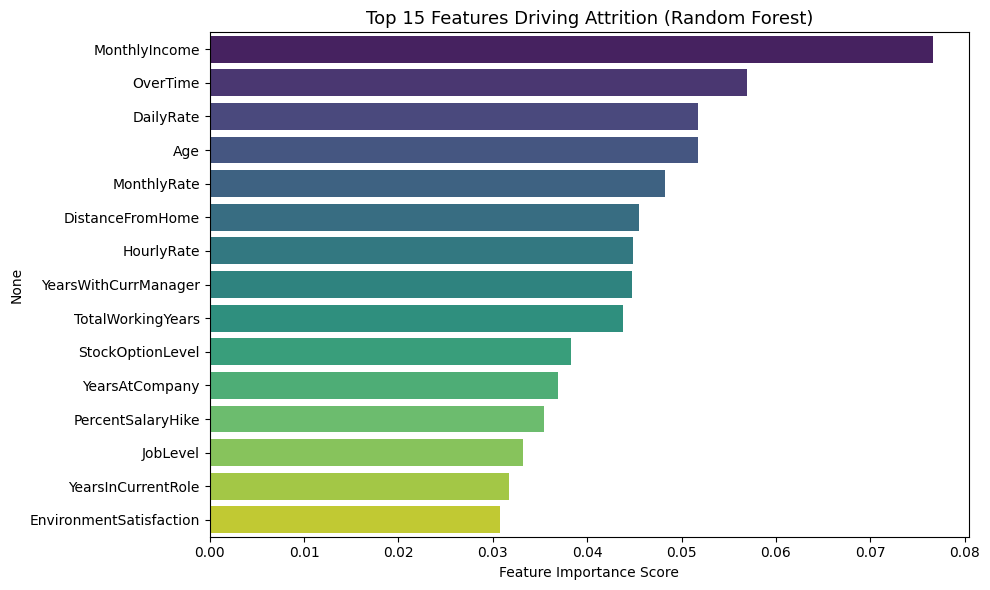

Saved.


In [27]:
feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
top_features = feat_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title('Top 15 Features Driving Attrition (Random Forest)', fontsize=13)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [28]:
thresholds = np.arange(0.3, 0.7, 0.05)

results = []
for t in thresholds:
    preds = (y_prob_lr >= t).astype(int)
    tp = ((preds == 1) & (y_test == 1)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    flagged = preds.sum()
    results.append({
        'Threshold': round(t, 2),
        'Flagged Employees': flagged,
        'Precision': round(precision, 2),
        'Recall': round(recall, 2),
        'True Positives': tp,
        'Missed (FN)': fn
    })

threshold_df = pd.DataFrame(results)
print(threshold_df.to_string(index=False))

 Threshold  Flagged Employees  Precision  Recall  True Positives  Missed (FN)
      0.30                171       0.24    0.85              41            7
      0.35                146       0.27    0.83              40            8
      0.40                127       0.30    0.79              38           10
      0.45                113       0.32    0.75              36           12
      0.50                 99       0.35    0.73              35           13
      0.55                 86       0.40    0.71              34           14
      0.60                 66       0.47    0.65              31           17
      0.65                 52       0.50    0.54              26           22


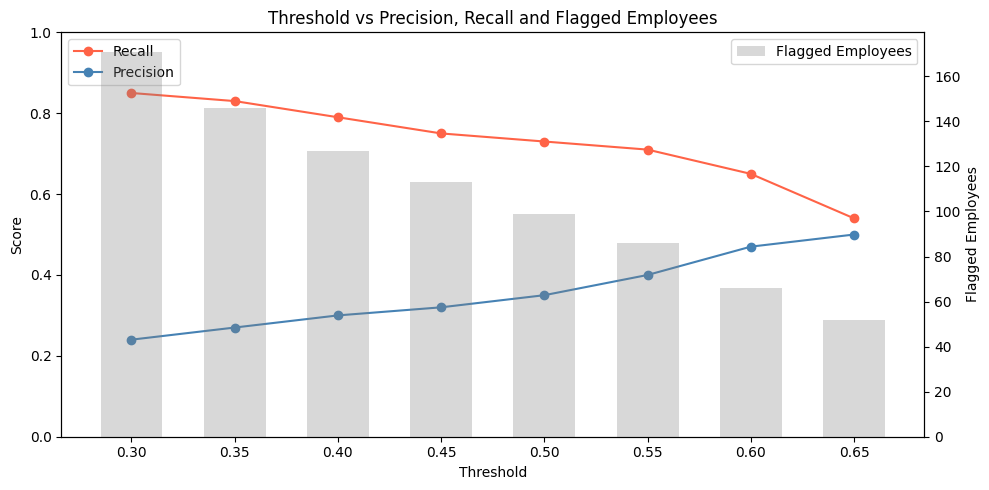

Saved.


In [29]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], 
         marker='o', color='tomato', label='Recall')
ax1.plot(threshold_df['Threshold'], threshold_df['Precision'], 
         marker='o', color='steelblue', label='Precision')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.bar(threshold_df['Threshold'], threshold_df['Flagged Employees'], 
        width=0.03, alpha=0.3, color='grey', label='Flagged Employees')
ax2.set_ylabel('Flagged Employees')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Threshold vs Precision, Recall and Flagged Employees')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

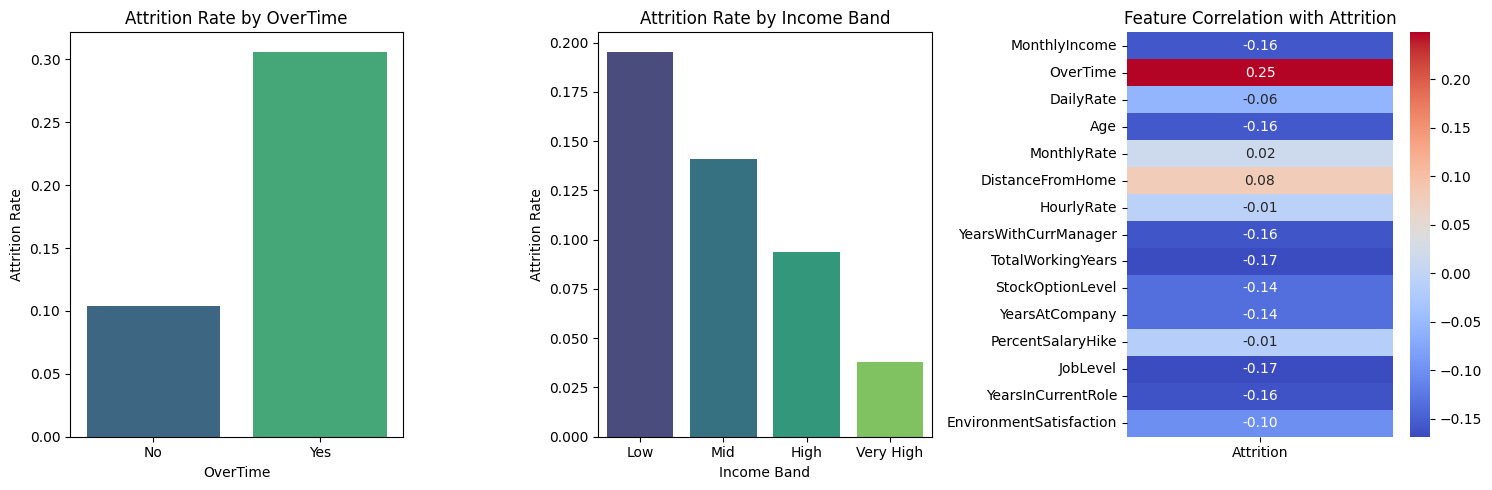

Saved.


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Attrition by OverTime
ot_counts = df.groupby('OverTime')['Attrition'].mean().reset_index()
ot_counts['OverTime_Label'] = ot_counts['OverTime'].map({1: 'Yes', 0: 'No'})
sns.barplot(x='OverTime_Label', y='Attrition', data=ot_counts, ax=axes[0], palette='viridis')
axes[0].set_title('Attrition Rate by OverTime')
axes[0].set_ylabel('Attrition Rate')
axes[0].set_xlabel('OverTime')

# Chart 2: Attrition by MonthlyIncome bucket
df['IncomeBucket'] = pd.cut(df['MonthlyIncome'], bins=4, 
                             labels=['Low', 'Mid', 'High', 'Very High'])
income_counts = df.groupby('IncomeBucket', observed=True)['Attrition'].mean().reset_index()
sns.barplot(x='IncomeBucket', y='Attrition', data=income_counts, ax=axes[1], palette='viridis')
axes[1].set_title('Attrition Rate by Income Band')
axes[1].set_ylabel('Attrition Rate')
axes[1].set_xlabel('Income Band')

# Chart 3: Correlation heatmap of top numeric features
top_feat_names = top_features.index.tolist()
corr_data = df[top_feat_names + ['Attrition']].corr()
sns.heatmap(corr_data[['Attrition']].drop('Attrition'), 
            annot=True, fmt='.2f', cmap='coolwarm', 
            ax=axes[2], cbar=True)
axes[2].set_title('Feature Correlation with Attrition')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'eda_charts.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [31]:
df_original = pd.read_csv(DATA_PATH)

In [32]:
THRESHOLD = 0.55
risk_probs = lr.predict_proba(X)[:, 1]
risk_flags = (risk_probs >= THRESHOLD).astype(int)

In [33]:
risk_report = pd.DataFrame({
    'EmpID': df_original['EmpID'],
    'Attrition_Probability': np.round(risk_probs, 3),
    'At_Risk': risk_flags
})

In [34]:
risk_report = risk_report.sort_values('Attrition_Probability', ascending=False)

In [35]:
at_risk = risk_report[risk_report['At_Risk'] == 1]
print(f"Total employees flagged at risk: {len(at_risk)}")
print(f"\nTop 20 highest risk employees:\n")
print(at_risk.head(20).to_string(index=False))

Total employees flagged at risk: 434

Top 20 highest risk employees:

 EmpID  Attrition_Probability  At_Risk
RM1087                  0.969        1
 RM915                  0.956        1
 RM657                  0.954        1
 RM799                  0.950        1
 RM027                  0.947        1
RM1286                  0.941        1
 RM749                  0.941        1
 RM238                  0.936        1
RM1059                  0.929        1
RM1354                  0.928        1
 RM537                  0.927        1
 RM464                  0.925        1
RM1224                  0.925        1
 RM938                  0.923        1
 RM893                  0.917        1
 RM948                  0.909        1
RM1427                  0.906        1
 RM546                  0.902        1
RM1333                  0.900        1
 RM912                  0.900        1


In [36]:
risk_report.to_csv(os.path.join(OUTPUT_PATH, 'employee_risk_report.csv'), index=False)
print("\nFull risk report saved to outputs/")


Full risk report saved to outputs/


In [37]:
risk_report['Actual_Attrition'] = df_original['Attrition'].values

# Summary
print(f"Total flagged: {len(at_risk)}")
print(f"Of flagged, actually left: {risk_report[risk_report['At_Risk']==1]['Actual_Attrition'].value_counts().to_dict()}")
print(f"\nTop 20 highest risk:")
print(risk_report[risk_report['At_Risk']==1][['EmpID','Attrition_Probability','Actual_Attrition']].head(20).to_string(index=False))

risk_report.to_csv(os.path.join(OUTPUT_PATH, 'employee_risk_report.csv'), index=False)
print("\nSaved.")

Total flagged: 434
Of flagged, actually left: {'No': 322, 'Yes': 112}

Top 20 highest risk:
 EmpID  Attrition_Probability Actual_Attrition
RM1087                  0.969              Yes
 RM915                  0.956               No
 RM657                  0.954              Yes
 RM799                  0.950               No
 RM027                  0.947              Yes
RM1286                  0.941               No
 RM749                  0.941              Yes
 RM238                  0.936               No
RM1059                  0.929              Yes
RM1354                  0.928               No
 RM537                  0.927              Yes
 RM464                  0.925              Yes
RM1224                  0.925              Yes
 RM938                  0.923              Yes
 RM893                  0.917               No
 RM948                  0.909              Yes
RM1427                  0.906               No
 RM546                  0.902              Yes
RM1333         